# Additional analysis of potential relations:

* correlation of ANS acuity (n2_evidence_sd) with risky_prior_mu
* sim. if stress --> ∂prob. --> risky_prior_mu

## correlation of ANS acuity (n2_evidence_sd) with risky_prior_mu

In [6]:
import pandas as pd
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
#from bauer.utils.math import softplus_np

bids_folder = '/Users/mrenke/data/ds-stressrisk'
def softplus_np(x): return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0)


In [3]:
model_n = 1
idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-{model_n}_trace.netcdf'))

In [4]:
prior_mus= pd.concat((idata.posterior['safe_prior_mu'].to_dataframe(), (idata.posterior['risky_prior_mu'].to_dataframe())), axis=1)
prior_mus.columns.name = 'parameter'
prior_mus.index = prior_mus.index.set_names(['chain','draw','subject','regressor']) 
prior_mus = prior_mus.stack().to_frame('value')
prior_mus['Prior'] = prior_mus.index.get_level_values('parameter').map({'safe_prior_mu':'safe', 'risky_prior_mu':'risky'})

prior_mus = prior_mus.xs('Intercept', 0,'regressor')
prior_mus = prior_mus.groupby(['subject', 'parameter'])[['value']].mean()
risky_prior_mus = prior_mus.xs('risky_prior_mu',0,'parameter').rename(mapper={'value':'risky_prior_mu'},axis=1)
risky_prior_mus.head()

,risky_prior_mu
subject,
1,3.511950
2,3.369483
3,3.194726
4,3.202980
5,3.497174


In [7]:
evidence_sd = pd.concat((idata.posterior['n1_evidence_sd'].to_dataframe(), (idata.posterior['n2_evidence_sd'].to_dataframe())), axis=1)
evidence_sd.columns.name = 'parameter'
evidence_sd.index = evidence_sd.index.set_names(['chain','draw','subject','regressor']) # get handel on regressors #'subject',
evidence_sd = evidence_sd.stack().to_frame('value')
evidence_sd['Noise'] = evidence_sd.index.get_level_values('parameter').map({'n1_evidence_sd_mu':'n1', 'n2_evidence_sd_mu':'n2'})
evidence_sd['value_softpl'] = softplus_np(evidence_sd['value'])
evidence_sd = evidence_sd.xs('Intercept', 0,'regressor')
evidence_sd = evidence_sd.groupby(['subject', 'parameter']).mean()[['value_softpl']]

n2_evidence_sd = evidence_sd.xs('n2_evidence_sd',0,'parameter').rename(mapper={'value_softpl':'n2_evidence_sd'},axis=1)
n2_evidence_sd.head()

,n2_evidence_sd
subject,
1,0.145912
2,0.201931
3,0.194838
4,0.182300
5,0.163089


In [8]:
from stress_risk.utils.data import get_all_behavior

df = get_all_behavior(bids_folder=bids_folder)
objective_risky_mu = np.log(df.groupby(['subject'])[['n_risky']].mean())


/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [28]:
dif_priors_natural = risky_prior_mus.join(objective_risky_mu) # drops 3 unneeded subs from objective_risky_mu
dif_priors_natural['prior_dif'] = dif_priors_natural['n_risky'] -dif_priors_natural['risky_prior_mu']
df_comb = n2_evidence_sd.join(dif_priors_natural[['prior_dif']]) 
df_comb.head()

,n2_evidence_sd,prior_dif
subject,,
1,0.145912,-0.140067
2,0.201931,0.195028
3,0.194838,0.143164
4,0.182300,0.501609
5,0.163089,-0.131900


/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


Text(0.5, 1.0, 'r =0.2, p= 0.165')

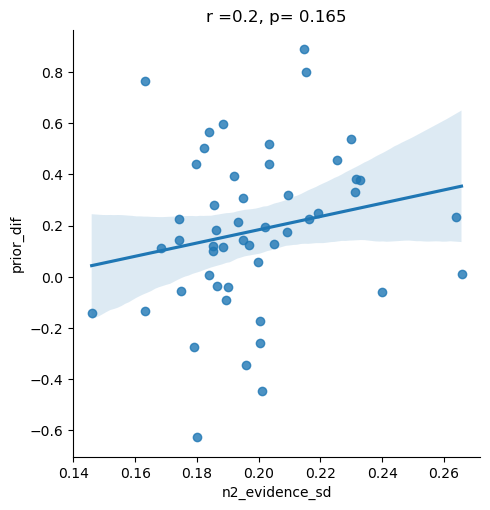

In [40]:
dif_priors_natural = dif_priors_natural.loc[n2_evidence_sd.index.unique()]
r = np.corrcoef(dif_priors_natural['prior_dif'],n2_evidence_sd['n2_evidence_sd'])[0, 1]

from scipy.stats import linregress
reg = linregress(dif_priors_natural['prior_dif'],n2_evidence_sd['n2_evidence_sd'])

import seaborn as sns

sns.lmplot(df_comb, x='n2_evidence_sd',y='prior_dif' )
plt.title(f'r ={np.round(reg[2],3)}, p= {np.round(reg[3],3)}')

--> in the proposed direction but not significant !

## simulation

 if (stress -->) ∂prob. --> ∂risky_prior_mu

In [56]:
from utils_02 import get_subwise_params

risky_prior_mu = get_subwise_params(idata, 'risky_prior_mu')
safe_prior_mu = get_subwise_params(idata, 'safe_prior_mu')
risky_prior_sd = get_subwise_params(idata, 'risky_prior_std')
safe_prior_sd = get_subwise_params(idata, 'safe_prior_std')
n1_ev_mu = get_subwise_params(idata, 'n1_evidence_sd')
n2_ev_mu = get_subwise_params(idata, 'n2_evidence_sd')

sub_params = pd.concat([risky_prior_mu, safe_prior_mu,risky_prior_sd,safe_prior_sd,n1_ev_mu,n2_ev_mu],axis=1)
sub_params.head()

,risky_prior_mu,safe_prior_mu,risky_prior_std,safe_prior_std,n1_evidence_sd,n2_evidence_sd
subject,,,,,,
1,3.511950,2.561211,-0.910787,-1.084006,-1.153115,-1.880260
2,3.369483,3.488596,-0.609618,-1.200628,-1.185866,-1.512110
3,3.194726,2.879364,-1.220158,-0.733372,-1.045374,-1.555680
4,3.202980,3.810281,-1.293644,-0.867947,-1.129907,-1.630347
5,3.497174,3.118516,-0.699055,-1.080456,-1.135886,-1.754081


In [ ]:
from utils_02 import simulate_choices_subind_p_var

    df_sim = simulate_choices_subind(df_ts_s, sub_params.set_index('subject'))
